# ASI Geometric Calibration

ASI geometric calibration, sometimes called star calibration, is the process of determining the azimuth and elevation corresponding to each pixel in an ASI image.  This is dependent not only on the lens, CCD, and configuration of the camera, but also how it is oriented in the field.  It is often easier to figure out the transformations that need to be applied to an image after the fact rather than precicely orienting it when deployed.  Geometic calibration is necessary to later determine where imaged features are physically occuring, which allows them to be plotted on maps and compared to other instrumentation.  This tutorial first illustrates and lays out the math for how this process occurs within the `asistarcalibration` package, then walks through the steps of using the package to generate azimuth and elevation maps for any ASI.


In [1]:
%matplotlib widget

import datetime as dt
import numpy as np
import os
import urllib
from PIL import Image
from skimage import exposure

import matplotlib as mpl
if mpl.get_backend() == 'macosx':
    mpl.use('tkagg')
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Circle, Rectangle
import mpl_toolkits.mplot3d.art3d as art3d
import cartopy.crs as ccrs

from asistarcalibration import starcal, starfinder

As light enters the ASI from different directions, the fish-eye lens focuses it on the CCD.  This means that different pixels in the CCD correspond to different parts of the sky.  For illustrative purposes, the following examples show an extremely corsely resolved CCD.  The code used to generate these examples is also purely for illustrative purposes and should not be needed or used elsewhere to perform geometric calibrations.

/var/folders/yf/c17s54f12c1bg0cxdywsxyxjssh4z4/T/ipykernel_97315/3316183976.py:35: RuntimeWarning: invalid value encountered in sqrt
  zg = np.sqrt(1-xg**2-yg**2)


[]

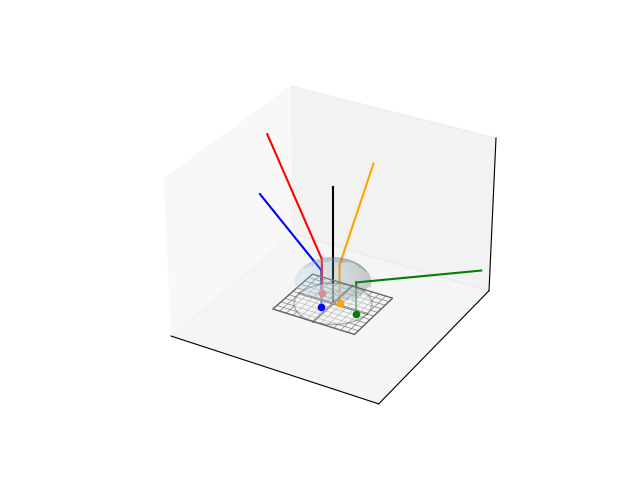

In [2]:
rays = np.array([[45., 80.], [190., 40.], [270., 55.],[300.,70]])
rays = [{'az':45, 'el':80, 'color':'orange'},
        {'az':100, 'el':40, 'color':'green'},
        {'az':210, 'el':70, 'color':'blue'},
        {'az':300, 'el':55, 'color':'red'}]

ccdcolor = 'dimgrey'
lenscolor = 'whitesmoke'

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
for r in rays:
    az, el = np.deg2rad([r['az'],r['el']])
    x = 6*np.cos(el)*np.sin(az)
    y = 6*np.cos(el)*np.cos(az)
    z = 6*np.sin(el)
    xi = np.cos(el)*np.sin(az)
    yi = np.cos(el)*np.cos(az)
    zi = np.sin(el)

    ax.plot([xi,x], [yi,y], [zi,z], color=r['color'])
    ax.plot([xi,xi], [yi,yi], [-1,zi], color=r['color'])

    ax.scatter(xi, yi, -1, color=r['color'])

p = Rectangle((-1.2,-1), 2.4, 2, fc='None', ec=ccdcolor)
ax.add_patch(p)
art3d.pathpatch_2d_to_3d(p, z=-1, zdir="z")

p = Circle((0, 0), 1, fc=lenscolor, ec=ccdcolor, alpha=0.5)
ax.add_patch(p)
art3d.pathpatch_2d_to_3d(p, z=-1, zdir="z")

xg, yg = np.meshgrid(np.linspace(-1.,1.,50), np.linspace(-1., 1., 50))
zg = np.sqrt(1-xg**2-yg**2)
ax.plot_surface(xg, yg, zg, color='lightblue', alpha=0.3)

ax.plot([-1, 1], [0,0], [-1,-1], color='black')
ax.plot([0,0], [-1, 1], [-1,-1], color='black')
ax.plot([0,0], [0,0], [-1,5], color='black')

for y0 in np.arange(-1., 1., 0.2):
    ax.plot([-1.2, 1.2], [y0,y0], [-1,-1], linewidth=0.5, color='grey')

for x0 in np.arange(-1.2, 1.4, 0.2):
    ax.plot([x0, x0], [-1, 1], [-1,-1], linewidth=0.5, color='grey')

ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])


## Transform Coordinates
The following shows the different coordinate transfomrations that are used to find the azimuth and elevation of each pixel.  This demonstration assumes various transformation constants are known.

In [3]:
# Illustrative example of different coordinate systems
x0 = 22
y0 = 17.5
rl = 16
w = 40
h = 34
C = 0.1
D = -0.5
A = np.pi/2
B = -(np.pi/2 + C + D)

rg = np.linspace(0., 1., 100)
lg = A + B * rg + C * rg**2 + D * rg**3

for r in rays:
    az, el = np.deg2rad([r['az'], r['el']])

    d = np.interp(el, lg[::-1], rg[::-1])
    xn = d*np.sin(az)
    yn = d*np.cos(az)

    r['xc'] = int(xn*rl + x0)
    r['yc'] = int(yn*rl + y0)

    r['xn'] = (r['xc'] - x0)/rl
    r['yn'] = (r['yc'] - y0)/rl


### CCD Coordinates
We will refer to the original data coordinate system as CCD coordinates ($x_c$,$y_c$).  Each pixel is defined by its integer location on the CCD.


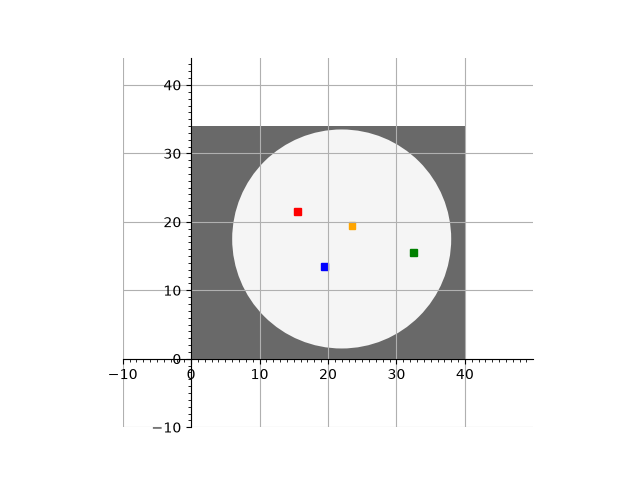

In [4]:
# CCD coords
fig, ax = plt.subplots()

p = Rectangle((0,0), w, h, fc=ccdcolor, ec='None', zorder=0)
ax.add_patch(p)

p = Circle((x0, y0), rl, fc=lenscolor, ec='None', zorder=1)
ax.add_patch(p)

for r in rays:
    p = Rectangle((r['xc'], r['yc']), 1, 1, color=r['color'])
    ax.add_patch(p)

ax.set_xlim([-10,w+10])
ax.set_ylim([-10,h+10])
ax.set_xticks(np.arange(-10, w+10, 10))
ax.set_yticks(np.arange(-10, h+10, 10))
ax.set_xticks(np.arange(-10, w+10, 1), minor=True)
ax.set_yticks(np.arange(-10, h+10, 1), minor=True)
ax.set_aspect('equal')
ax.grid()
ax.spines[['bottom', 'left']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)


### Normalized Coordinates
In normalized coordinates, zenith is located at (0,0) and the horizon is at 1.  The normalized coordinate of each pixel can be found by subtracting the zenith position ($x_0$,$y_0$) and dividing by the lens radius $R_L$, both of which are expressed in CCD pixel units.

$$ x_n = (x_c-x_0)/R_L $$
$$ y_n = (y_c-y_0)/R_L $$


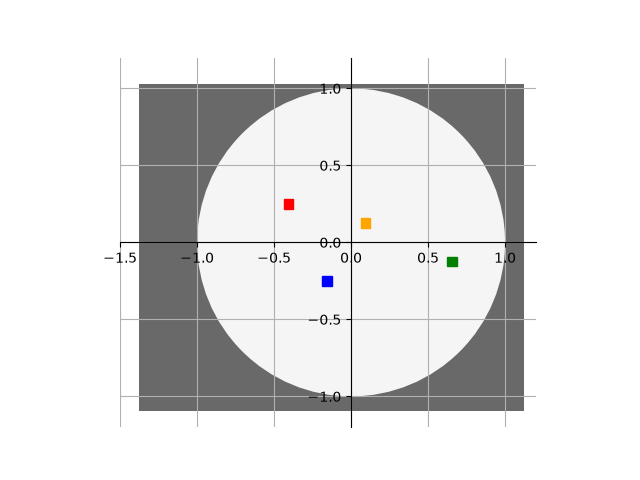

In [5]:
# Normalized coords
fig, ax = plt.subplots()

p = Rectangle((-x0/rl,-y0/rl), w/rl, h/rl, fc=ccdcolor, ec='None')
ax.add_patch(p)

p = Circle((0, 0), 1., fc=lenscolor, ec='None')
ax.add_patch(p)

for r in rays:
    p = Rectangle((r['xn'],r['yn']), 1./rl, 1./rl, color=r['color'])
    ax.add_patch(p)

ax.set_xlim([-1.5,1.2])
ax.set_ylim([-1.2,1.2])
ax.set_aspect('equal')
ax.grid()
ax.spines[['bottom', 'left']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)


### Az/El coordinates
In az/el coordinates, each pixel is represented by the azimuth and elevation of the corresponding location in the sky from an observer at the camera sight facing North.  Azimuth is the arctangent of the normalized coordinates plus the rotation angle $\theta$ that corresponds to the camera's orientation relative to North.  

$$ \phi = \theta - \arctan\left(\frac{x_n}{y_n}\right) $$

Elevation cannot be calculated from simple geometry due to the fact that real lenses do not provide a perfect transformation.  Instead, elevation is an empirically derived function of the distance in normalized coordinates from the center, called the **lens function**.

$$ r = \sqrt{x_n^2 + y_n^2} $$
$$ \lambda = A + Br + Cr^2 + Dr^3 $$

Given $\lambda=\pi/2$ at $r=0$ and $\lambda=0$ at $r=1$, two of the four parameters are fully constrained.

$$ A=\pi/2 $$
$$ B = -(\pi/2 + C + D) $$


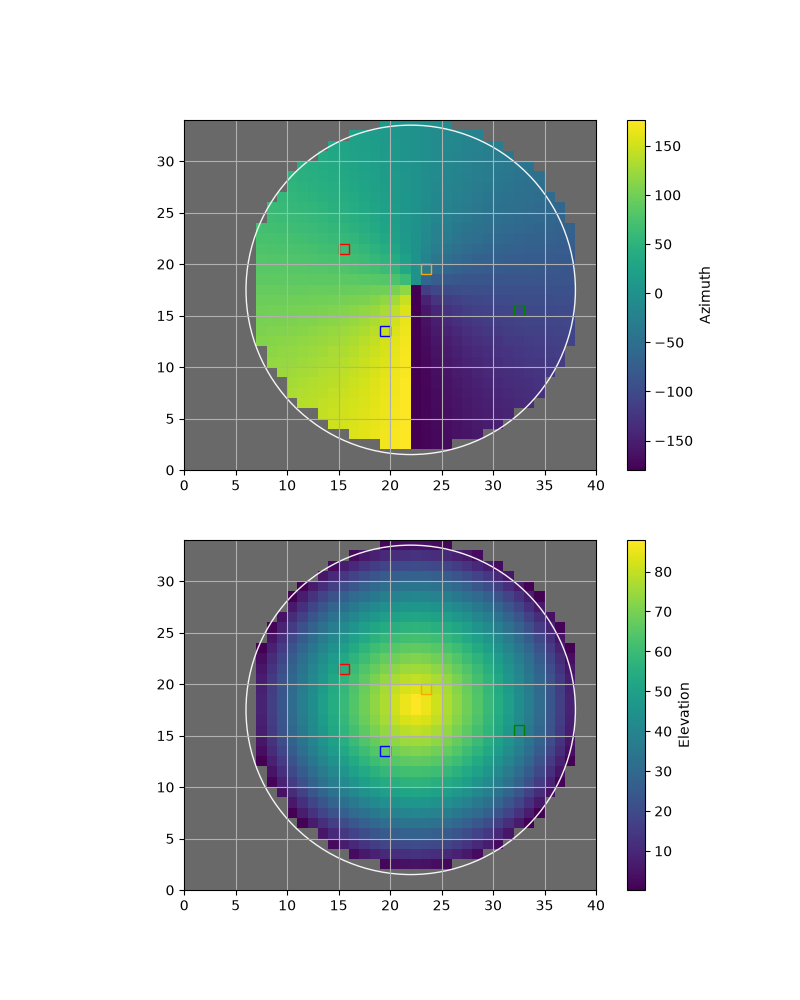

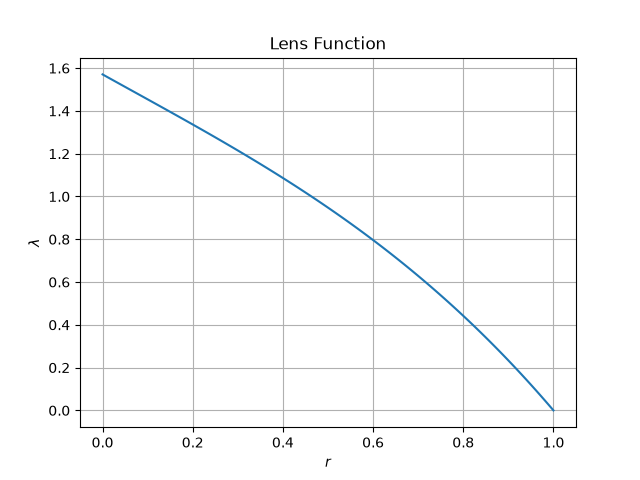

In [6]:
# Az/El coords
fig, [axa, axe] = plt.subplots(2,1, figsize=(8,10))

xcgrid, ycgrid = np.meshgrid(np.arange(w+1), np.arange(h+1))
xgrid_cent = np.diff(xcgrid[:,:-1], axis=0)/2 + xcgrid[:-1,:-1]
ygrid_cent = np.diff(ycgrid[:-1,:], axis=1)/2 + ycgrid[:-1,:-1]
xngrid = (xgrid_cent-x0)/rl
yngrid = (ygrid_cent-y0)/rl
azgrid = np.rad2deg(-np.arctan2(xngrid, yngrid))
rg = np.sqrt(xngrid**2 + yngrid**2)
elgrid = np.rad2deg(A + B*rg + C*rg**2 + D*rg**3)

azgrid[rg>1] = np.nan
elgrid[rg>1] = np.nan

c = axa.pcolormesh(xcgrid, ycgrid, azgrid)
fig.colorbar(c, label='Azimuth')

p = Rectangle((0,0), w, h, fc=ccdcolor, ec='None', zorder=0)
axa.add_patch(p)

p = Circle((x0, y0), rl, fc='None', ec=lenscolor)
axa.add_patch(p)

for r in rays:
    p = Rectangle((r['xc'], r['yc']), 1, 1, ec=r['color'], fc='None')
    axa.add_patch(p)
    
axa.set_aspect('equal')
axa.grid()

c = axe.pcolormesh(xcgrid, ycgrid, elgrid)
fig.colorbar(c, label='Elevation')

p = Rectangle((0,0), w, h, fc=ccdcolor, ec='None', zorder=0)
axe.add_patch(p)

p = Circle((x0, y0), rl, fc='None', ec=lenscolor)
axe.add_patch(p)

for r in rays:
    p = Rectangle((r['xc'], r['yc']), 1, 1, ec=r['color'], fc='None')
    axe.add_patch(p)
    
axe.set_aspect('equal')
axe.grid()

fig, ax = plt.subplots()
r = np.linspace(0, 1, 100)
lam = A + B*r + C*r**2 + D*r**3

ax.plot(r, lam)
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\lambda$')
ax.set_title('Lens Function')
ax.grid()


## Star Fitting
The above transformation from CCD coordinates to azimuth and elevation requires 6 constants:

- $x_0$
- $y_0$
- $R_L$
- $\theta$
- $C$
- $D$

(Note that the lens function coefficients $A$ and $B$ are constrained by the lens function's required endpoints.)  These constants are unique to each deployment of every camera.  These constants can be calculated empirically with a generic nonlinear optimization or curve fitting function, provided a set of reference points in the image where the exact azimuth and elevation of a particular pixel is known.  The easiest way to generate these referance points is with the stars and planetary objects seen in the image, which have known azimuths and elevations.

## Using `asistarcalibration`

The `asistarcalibration` package has two main classes:

- `StarFinder` creates an interface to make it easier for users to identify stars in an image
- `StarCal` performs the actual star fitting given a list of stars

Both functions can be used independently, but there is also a `wizard` function that will walk through the entire process.

### Prepare Calibration Image
Find an image from your ASI where stars are clearly visable.  This is likely a time with no clouds and moon down, preferably with minimal aurora.  Because auroral ASI imagers usually have very narrow band filters, the stars are likely to be very dim and additional processing (ie, histogram equalization or contrast adjustments) may be necessary to adequately visualize them.  Coadding multiple images may also be useful, but make sure to not include so many that the stars begin to move appreciably.

The following example shows a raw image and one that has coadding and contrast adjustment so more stars are visable.  Note that for each camera, the exact procedure that is needed to generate an image with visable stars differs, so this step is left to the user and not done automatically in `asistarcalibration`.

In [7]:
# Download some example images
filelist = ['PFRR_20250103_032703_0558.png',
            'PFRR_20250103_032711_0558.png',
            'PFRR_20250103_032719_0558.png',
            'PFRR_20250103_032728_0558.png',
            'PFRR_20250103_032737_0558.png',
            'PFRR_20250103_032745_0558.png',
            'PFRR_20250103_032753_0558.png',
            'PFRR_20250103_032802_0558.png',
            'PFRR_20250103_032810_0558.png',
            'PFRR_20250103_032818_0558.png',
            'PFRR_20250103_032826_0558.png',
            'PFRR_20250103_032834_0558.png',
            'PFRR_20250103_032842_0558.png',
            'PFRR_20250103_032851_0558.png',
           ]
baseurl = 'https://optics.gi.alaska.edu/amisr_archive/PKR/DASC/PNG/2025/20250103/03/'

for filename in filelist:
    url = baseurl + filename
    print('Downloading data file... '+filename)
    urllib.request.urlretrieve(url, filename)
    # print('...Done!')

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1082)>

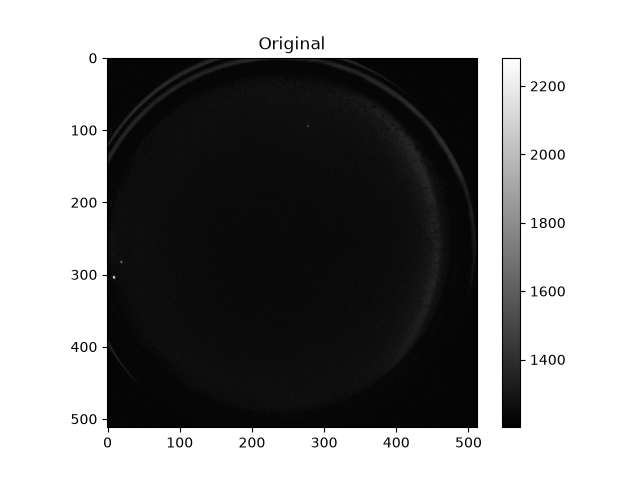

In [8]:
filename = 'PFRR_20250103_032703_0558.png'
img = Image.open(filename)

fig, ax = plt.subplots()
c = ax.imshow(img, cmap='grey')
ax.set_title('Original')
fig.colorbar(c)

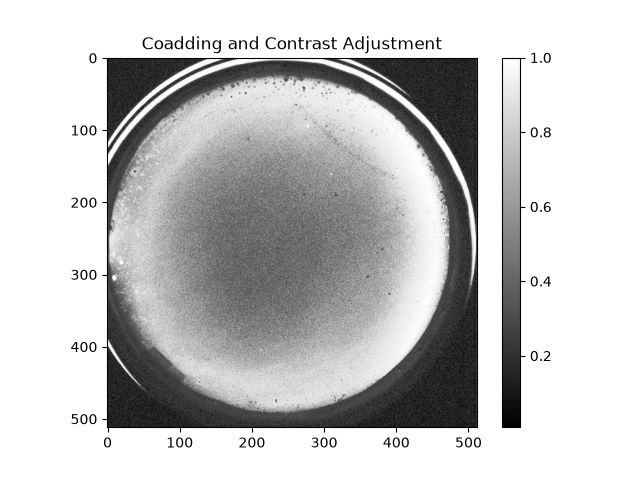

In [9]:
imglist = list()
for file in filelist:
    im = Image.open(file)
    imglist.append(im)
img = np.mean(imglist, axis=0)

# img_eq = equalize(img, 98.)
# p2, p98 = np.percentile(img, (30, 95))
# img_eq = exposure.rescale_intensity(img, in_range=(p2, p98))
img_eq = exposure.equalize_hist(img)

fig, ax = plt.subplots()
# c = ax.imshow(img_eq, cmap='grey', vmin=1240, vmax=1290)
c = ax.imshow(img_eq, cmap='grey')
ax.set_title('Coadding and Contrast Adjustment')
fig.colorbar(c)

### Identify Stars

Initialize the `StarFinder` class with the site longitude, latitude, and time of the frame you will be using to identify stars.  Then call the function `find_stars` with the processed image array as input.  This will cause a window to pop up displaying the image.  

**NOTE:** The script `starfind_example.py` (displayed below, but included in the root of the repository) is a minimal example of using the `StarFinder` class, but it will not run within a notebook.  Open a terminal window (or a terminal tab if running this in jupyter lab) and run this example.

```
python starfind_example.py
```

In [10]:
%pycat starfind_example.py

# starfind_example.py
# minimal example to run StarFinder

import numpy as np
from PIL import Image
from skimage import exposure
from asistarcalibration import starcal, starfinder

filelist = ['PFRR_20250103_032703_0558.png',
            'PFRR_20250103_032711_0558.png',
            'PFRR_20250103_032719_0558.png',
            'PFRR_20250103_032728_0558.png',
            'PFRR_20250103_032737_0558.png',
            'PFRR_20250103_032745_0558.png',
            'PFRR_20250103_032753_0558.png',
            'PFRR_20250103_032802_0558.png',
            'PFRR_20250103_032810_0558.png',
            'PFRR_20250103_032818_0558.png',
            'PFRR_20250103_032826_0558.png',
            'PFRR_20250103_032834_0558.png',
            'PFRR_20250103_032842_0558.png',
            'PFRR_20250103_032851_0558.png',
           ]

imglist = list()
for file in filelist:
    im = Image.open(file)
    imglist.append(im)
img = np.mean(imglist, axis=0)
img_eq = exposure.equalize_hist(img)

time = np.datetime

To identify stars, you need an astronomy program such as [Stellarium](https://stellarium.org).  The `StarFinder` class uses the [Skyfield](https://rhodesmill.org/skyfield/) library to calculate the position of stars and planets relative to the camera site.  Stars are refrenced from the [Hipparcos catalog](https://www.cosmos.esa.int/web/hipparcos/catalogues) and must be refrenced by their catolog number (HIP).  Any astronomy program or maps can be used as long as they include the HIP for different stars.

The terminal window running your star finding script should have the time and coordinates printed.  Configuring the following in Stellarium.

1. In the Configuration window (F2), under the "Extras" tab in "Additional information and settings" check "Use decimal degrees".
2. Pause time progression by hitting the "Play/Pause" button in the lower pop up bar or by pressing "K".
3. In the Location window (F6), set the latitude and longitude of the site.  Check "Use custom time zone" and set the time zone in the drop down menu to "UTC+00:00". If you want to make it easier to pull up this site in the future, enter the site name/abbreviation in the "Name/City" field and click "Add to list".
4. In the Date/time window (F5), set the date and time.
5. In the Sky and viewing options window (F4),  under the "Sky" tab in "Projection" select "Fish-eye". Depending on the specifics of the camera, a different projection may better match the image produced by the star finding script.
6. In the lower pop up bar, turn off all constellation highlighting, any grids, deep sky objects, planet labels, exoplanets, meteroid showers, and artificial satellites.  It is usually helpful to have "Ground" on.  "Atmosphere" may or may not be helpful.
7. Rotate the view and zoom in or out so you can see the entire circle of the sky on your screen.

![title](Screenshot1.png)

This shows the three screens windows that you will need for identifying stars side-by-side, but it may be easier to flip between windows or put them on diffent screens so everything is larger.

You must identify points in the ASI image and match them to the planets and stars in Stellarium.  It may be useful to identify common constellations to start.  Note that in narrow-band filtered images, stars will not have the same relative brightness as in astronomical star charts.

![title](Screenshot2.png)

When you select an object in Stellarium, its name and other information will appear in the left side of the window.  Double click on the analogous point in the image window and a blue dot will appear marking the identified star.  In the terminal window, a prompt will appear for you to identify the object.  For planets, enter the planet name.

![title](Screenshot3.png)

After an object is sucessfully entered, the blue dot on the image will turn into a red circle.  Continue selecting points in the image window and entering their identifiers in the terminal window.  For stars, you MUST enter the Hipparcos number (HIP) rather than the star name.

![title](Screenshot4.png)

A good star calibration will ideally have 10-20 stars identified roughly uniformly scattered across the FoV (ie, not all in the same azimuth sector).  At minimum, you should have 6 stars to fully constrain the 6 unknowns.


The output file is a text file which includes a header with some optional site information, the time that was used to identify the star positions, and the coordinates of the site.  Each row is an identified star/planet, which its name and HIP number (unnamed stars are marked with "xxxxx" and planets which do not appear in the HIP catalog will appear as "0"), that star's azimuth and elevation coordinates from astronomical calculations, and its position in CCD coordinates (x, y).

In [11]:
%cat test_out.txt

# NONE    None
# 2025-01-03T03:27:00+00:00
# GLAT=   65.000000    GLON= -147.000000
################################################################################
           Name      HIP              az              el          x          y
        Jupiter        0      104.382729       30.588443 276.980292  94.592018
        Capella    24608       80.670864       48.028234 309.356098 160.730917
           Vega    91262      287.405432       35.281529 212.483780 404.022050
          Deneb   102098      265.725173       53.689328 185.083267 340.725704
          Venus        0      214.626424        7.959395  19.191947 283.547405
          Dubhe    54061       12.673244       37.610431 379.598305 292.183675
          Merak    53910       14.220957       32.388595 392.022152 291.355418

### Parameter Fitting
The `StarCal` class performs the actual fitting of stars to recover the 6 unown parameters.  It is initialized with the output star file shown above.

The `calculate_calibration_params` function performs the actual fitting and generates a summary plot of the star true locations compared to the transformed locations of the analogous CCD pixels, as well as the lens function found.  If there is a serious mismatch in either of these plots, it is likely that there is one or more "bad" stars in the starfile (ie, stars that have been incorrectly recorded).  Delete these rows and try the calibration again.

X0=238.78624514031736
Y0=254.6626039345663
RL=240.91920270321899
THETA=207.52006697919663
A=90.0
B=-85.2233922113087
C=0.2520243731709782
D=-5.02863216186227


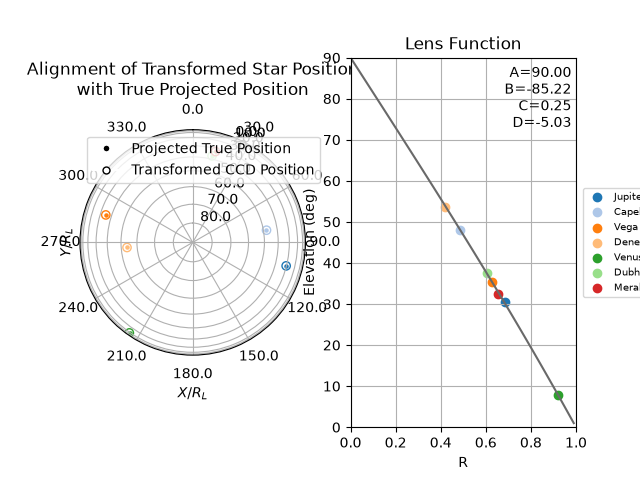

x0 = 238.78624514031736
y0 = 254.6626039345663
RL = 240.91920270321899
theta = 207.52006697919663
A = 1.5707963267948966
B = -1.487428793805828
C = 0.004398655107108432
D = -0.08776618809617705


In [12]:
sc = starcal.StarCal('test_out.txt')
sc.calculate_calibration_params(*img_eq.shape)

print(f'x0 = {sc.x0}')
print(f'y0 = {sc.y0}')
print(f'RL = {sc.rl}')
print(f'theta = {sc.theta}')
print(f'A = {sc.A}')
print(f'B = {sc.B}')
print(f'C = {sc.C}')
print(f'D = {sc.D}')


Additionally, the `checkcal` function provides an additional sainity check by overlaying elevation circles on the original image.  The stars used for the fit are marked by dots with the face color representing the star's azimuth and the edge color the star's elevation.  The star elevations should match the overlaying elevation circles.  The dodded line represents North, which should conform to the pattern shown by the face colors.  The red plus and pink star show where zenith and Polaris are nominally located in the image.

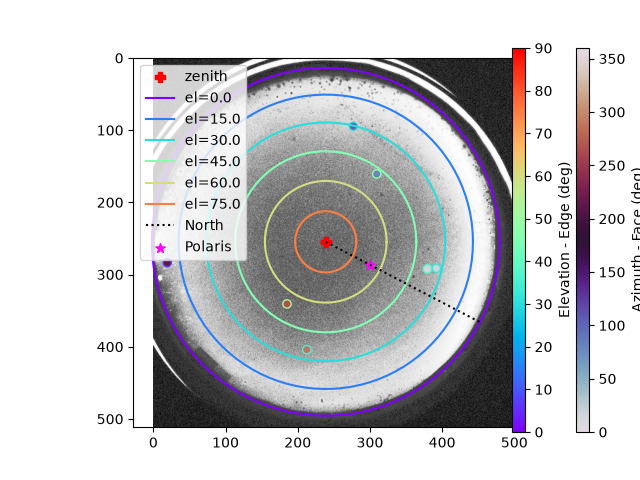

In [13]:
sc.checkcal(img_eq, 65.5)

### Position Arrays
Once the parameters that are needed for the transformation have been determined, the azimuth and elevation arrays for every pixel on the CCD, as well as the latitude and longitude arrays for the image projected to a particular altitude, can be found from the `calculate_position_array` function.

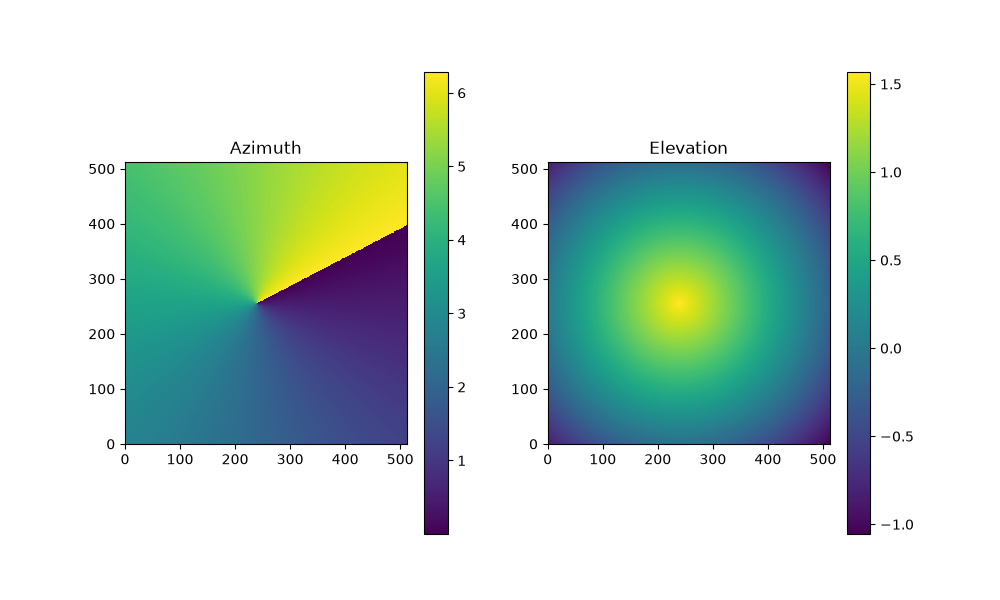

In [14]:
glat = 65.5
glon = -147.7
alt = 110.

az, el, lat, lon = sc.calculate_position_array(glat, glon, alt, *img_eq.shape)

fig, [ax1, ax2] = plt.subplots(1,2, figsize=(10,6))
c = ax1.pcolormesh(az)
ax1.set_aspect('equal')
ax1.set_title('Azimuth')
fig.colorbar(c)
c = ax2.pcolormesh(el)
ax2.set_aspect('equal')
ax2.set_title('Elevation')
fig.colorbar(c)

### Wizard
The `asistarcalibration` package includes a wizard function that encompases both the star finding and fitting steps.  This will output both the starlist text file and an hdf5 file with complete azimuth, elevation, latitude, longitude, and magnetic footpointed arrays to match the image.

```python
from asistarcalibration import wizard

######################################
# calibration image preparation here
######################################

wizard(img, site_lat, site_lon, time, 
           starlist='starlist.txt', 
           outfile='pixelcoords.h5', 
           projalt=110., 
           elevcutoff=15.,
           footalt=110.,
           starfind = True,
           plot_kw=dict()):
```

## Map Image
To plot the image on a geographic map, use the `lat` and `lon` array.

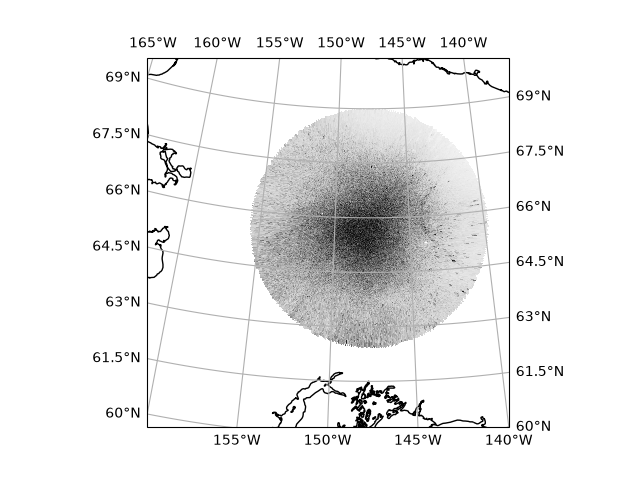

In [15]:
proj = ccrs.Orthographic(central_longitude=-147.7, central_latitude=65.5)

fig, ax = plt.subplots(subplot_kw={'projection':proj})

im = img_eq.copy()
im[el<np.deg2rad(15.)] = np.nan

c = ax.pcolormesh(lon, lat, im, cmap='grey', transform=ccrs.PlateCarree())
ax.set_extent([-160, -140, 60., 70.])
ax.coastlines()
ax.gridlines(draw_labels=True)